In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np

def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, 2 * (i // 2) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, i) for i in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])

    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])

    return sinusoid_table

pos = 7
d_model = 4
i = 0

print("Positional Encoding 값:\n", positional_encoding(pos, d_model))

print("")
print("if pos == 0, 2i == 0 (sin): ", np.sin(0 / np.power(10000, 2 * i / d_model)))
print("if pos == 1, 2i == 0 (sin): ", np.sin(1 / np.power(10000, 2 * i / d_model)))
print("if pos == 2, 2i == 0 (sin): ", np.sin(2 / np.power(10000, 2 * i / d_model)))
print("if pos == 3, 2i == 0 (sin): ", np.sin(3 / np.power(10000, 2 * i / d_model)))

print("")
print("if pos == 0, 2i+1 == 1 (cos): ", np.cos(0 / np.power(10000, 2 * i / d_model)))
print("if pos == 1, 2i+1 == 1 (cos): ", np.cos(1 / np.power(10000, 2 * i / d_model)))
print("if pos == 2, 2i+1 == 1 (cos): ", np.cos(2 / np.power(10000, 2 * i / d_model)))
print("if pos == 3, 2i+1 == 1 (cos): ", np.cos(3 / np.power(10000, 2 * i / d_model)))

Positional Encoding 값:
 [[ 0.          1.          0.          1.        ]
 [ 0.84147098  0.54030231  0.00999983  0.99995   ]
 [ 0.90929743 -0.41614684  0.01999867  0.99980001]
 [ 0.14112001 -0.9899925   0.0299955   0.99955003]
 [-0.7568025  -0.65364362  0.03998933  0.99920011]
 [-0.95892427  0.28366219  0.04997917  0.99875026]
 [-0.2794155   0.96017029  0.05996401  0.99820054]]

if pos == 0, 2i == 0 (sin):  0.0
if pos == 1, 2i == 0 (sin):  0.8414709848078965
if pos == 2, 2i == 0 (sin):  0.9092974268256817
if pos == 3, 2i == 0 (sin):  0.1411200080598672

if pos == 0, 2i+1 == 1 (cos):  1.0
if pos == 1, 2i+1 == 1 (cos):  0.5403023058681398
if pos == 2, 2i+1 == 1 (cos):  -0.4161468365471424
if pos == 3, 2i+1 == 1 (cos):  -0.9899924966004454


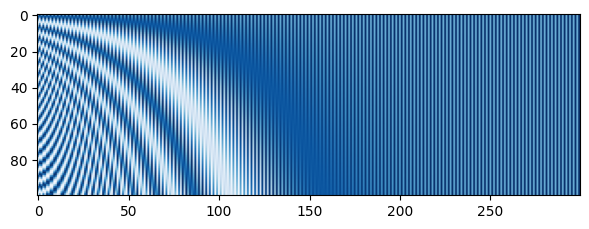

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.imshow(positional_encoding(100, 300), cmap='Blues')
plt.show()

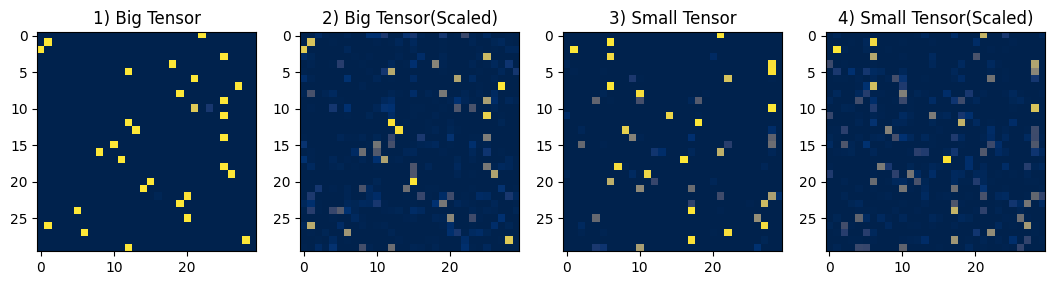

In [4]:
import torch
import matplotlib.pyplot as plt

def make_dot_product_tensor(shape):
    A = torch.rand(shape) * 6 - 3  # uniform distribution between -3 and 3
    B = (torch.rand(shape) * 6 - 3).transpose(0, 1)

    return torch.tensordot(A, B, dims=1)

length = 30
big_dim = 1024.
small_dim = 10.

big_tensor = make_dot_product_tensor((length, int(big_dim)))
scaled_big_tensor = big_tensor / torch.sqrt(torch.tensor(big_dim))
small_tensor = make_dot_product_tensor((length, int(small_dim)))
scaled_small_tensor = small_tensor / torch.sqrt(torch.tensor(small_dim))

fig = plt.figure(figsize=(13, 6))

ax1 = fig.add_subplot(141)
ax2 = fig.add_subplot(142)
ax3 = fig.add_subplot(143)
ax4 = fig.add_subplot(144)

ax1.set_title('1) Big Tensor')
ax2.set_title('2) Big Tensor(Scaled)')
ax3.set_title('3) Small Tensor')
ax4.set_title('4) Small Tensor(Scaled)')

ax1.imshow(torch.softmax(big_tensor, dim=-1).detach().numpy(), cmap='cividis')
ax2.imshow(torch.softmax(scaled_big_tensor, dim=-1).detach().numpy(), cmap='cividis')
ax3.imshow(torch.softmax(small_tensor, dim=-1).detach().numpy(), cmap='cividis')
ax4.imshow(torch.softmax(scaled_small_tensor, dim=-1).detach().numpy(), cmap='cividis')

plt.show()

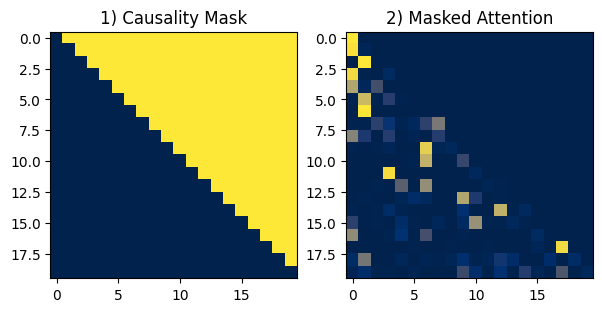

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt

def make_dot_product_tensor(shape):
    A = torch.rand(shape) * 6 - 3  # uniform distribution between -3 and 3
    B = (torch.rand(shape) * 6 - 3).transpose(0, 1)

    return torch.tensordot(A, B, dims=1)

def generate_causality_mask(seq_len):
    mask = 1 - np.cumsum(np.eye(seq_len, seq_len), 0)
    return mask

sample_tensor = make_dot_product_tensor((20, 512))
sample_tensor = sample_tensor / torch.sqrt(torch.tensor(512.))

mask = generate_causality_mask(sample_tensor.shape[0])

fig = plt.figure(figsize=(7, 7))

ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

ax1.set_title('1) Causality Mask')
ax2.set_title('2) Masked Attention')

ax1.imshow((torch.ones(sample_tensor.shape) + torch.tensor(mask)).detach().numpy(), cmap='cividis')

mask *= -1e9
ax2.imshow(torch.softmax(sample_tensor + torch.tensor(mask), dim=-1).detach().numpy(), cmap='cividis')

plt.show()

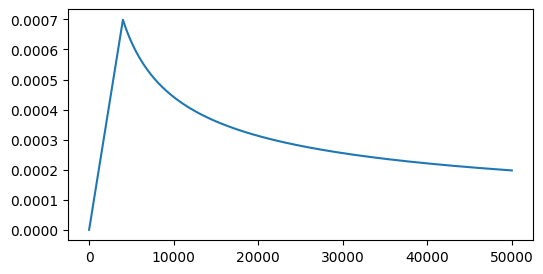

In [6]:
import matplotlib.pyplot as plt
import numpy as np

d_model = 512
warmup_steps = 4000

lrates = []
for step_num in range(1, 50000):
    lrate = (np.power(d_model, -0.5)) * np.min(
        [np.power(step_num, -0.5), step_num * np.power(warmup_steps, -1.5)])
    lrates.append(lrate)

plt.figure(figsize=(6, 3))
plt.plot(lrates)
plt.show()

Transformer로 번역기 만들기 [프로젝트]

In [7]:
!apt-get -qq install -y fonts-nanum > /dev/null

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

%config InlineBackend.figure_format = 'retina'

fontpath = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
fm.fontManager.addfont(fontpath) # 폰트를 matplotlib 에 등록
plt.rc('font', family=fm.FontProperties(fname=fontpath).get_name())
plt.rc('axes', unicode_minus=False)

print("슝=3")

슝=3


In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

import re
import os
import random

import seaborn # Attention 시각화를 위해 필요!

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(torch.__version__)
print("device:", device)   # cuda 가 나와야 GPU 가 잘 연결된 것입니다.

2.11.0+cu128
device: cuda


In [9]:
def positional_encoding(pos, d_model):
    def cal_angle(position, i):
        return position / np.power(10000, 2 * (i // 2) / d_model)

    def get_posi_angle_vec(position):
        return [cal_angle(position, hid_j) for hid_j in range(d_model)]

    sinusoid_table = np.array([get_posi_angle_vec(pos_i) for pos_i in range(pos)])
    sinusoid_table[:, 0::2] = np.sin(sinusoid_table[:, 0::2])
    sinusoid_table[:, 1::2] = np.cos(sinusoid_table[:, 1::2])
    return sinusoid_table

print("슝=3")

슝=3


In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model

        self.depth = d_model // self.num_heads

        self.W_q = nn.Linear(d_model, d_model)  # Linear Layer
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)

        self.linear = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask):
        d_k = K.size(-1)
        QK = torch.matmul(Q, K.transpose(-2, -1))

        scaled_qk = QK / torch.sqrt(torch.tensor(d_k, dtype=torch.float32))

        if mask is not None:
            scaled_qk += (mask * -1e9)

        attentions = F.softmax(scaled_qk, dim=-1)
        out = torch.matmul(attentions, V)

        return out, attentions

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.depth)
        x = x.permute(0, 2, 1, 3)

        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.permute(0, 2, 1, 3)
        x = x.contiguous().view(batch_size, -1, self.d_model)

        return x

    def forward(self, Q, K, V, mask=None):
        WQ = self.W_q(Q)
        WK = self.W_k(K)
        WV = self.W_v(V)

        WQ_splits = self.split_heads(WQ)
        WK_splits = self.split_heads(WK)
        WV_splits = self.split_heads(WV)

        out, attention_weights = self.scaled_dot_product_attention(
            WQ_splits, WK_splits, WV_splits, mask)

        out = self.combine_heads(out)
        out = self.linear(out)

        return out, attention_weights

print("슝=3")

슝=3


In [11]:
class PoswiseFeedForwardNet(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PoswiseFeedForwardNet, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.relu(self.w_1(x))
        out = self.w_2(out)

        return out

print("슝=3")

슝=3


In [12]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()

        self.enc_self_attn = MultiHeadAttention(d_model, n_heads)
        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        """
        Multi-Head Attention
        """
        residual = x
        out = self.norm_1(x)
        out, enc_attn = self.enc_self_attn(out, out, out, mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_2(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, enc_attn

print("슝=3")

슝=3


In [13]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()

        self.dec_self_attn = MultiHeadAttention(d_model, num_heads)   # 디코더 자기 자신을 보는 어텐션
        self.enc_dec_attn = MultiHeadAttention(d_model, num_heads)    # 인코더 출력을 보는 어텐션

        self.ffn = PoswiseFeedForwardNet(d_model, d_ff)

        self.norm_1 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_2 = nn.LayerNorm(d_model, eps=1e-6)
        self.norm_3 = nn.LayerNorm(d_model, eps=1e-6)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        """
        x            : 디코더 입력           [batch, tgt_len, d_model]
        enc_out      : 인코더 최종 출력       [batch, src_len, d_model]
        dec_enc_mask : 인코더-디코더 어텐션용  [batch, 1, 1, src_len]        (소스 <PAD> 가림)
        dec_mask     : 디코더 셀프 어텐션용    [batch, 1, tgt_len, tgt_len]  (미래 토큰 + 타겟 <PAD> 가림)
        """

        """
        Masked Multi-Head Attention — Q, K, V 모두 디코더 자신
        """
        residual = x
        out = self.norm_1(x)
        out, dec_attn = self.dec_self_attn(out, out, out, dec_mask)
        out = self.dropout(out)
        out += residual

        """
        Multi-Head Attention — Q 는 디코더, K·V 는 인코더 출력
        """
        residual = out
        out = self.norm_2(out)
        out, dec_enc_attn = self.enc_dec_attn(out, enc_out, enc_out, dec_enc_mask)
        out = self.dropout(out)
        out += residual

        """
        Position-Wise Feed Forward Network
        """
        residual = out
        out = self.norm_3(out)
        out = self.ffn(out)
        out = self.dropout(out)
        out += residual

        return out, dec_attn, dec_enc_attn

print("슝=3")

슝=3


In [14]:
class Encoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Encoder, self).__init__()
        self.n_layers = n_layers
        self.enc_layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, mask):
        out = x
        enc_attns = []

        for i in range(self.n_layers):
            out, enc_attn = self.enc_layers[i](out, mask)
            enc_attns.append(enc_attn)

        return out, enc_attns

print("슝=3")

슝=3


In [15]:
class Decoder(nn.Module):
    def __init__(self, n_layers, d_model, n_heads, d_ff, dropout):
        super(Decoder, self).__init__()
        self.n_layers = n_layers
        self.dec_layers = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, x, enc_out, dec_enc_mask, dec_mask):
        out = x

        dec_attns = []
        dec_enc_attns = []
        for i in range(self.n_layers):
            out, dec_attn, dec_enc_attn = \
                self.dec_layers[i](out, enc_out, dec_enc_mask, dec_mask)

            dec_attns.append(dec_attn)
            dec_enc_attns.append(dec_enc_attn)

        return out, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [16]:
class Transformer(nn.Module):
    def __init__(self,
                 n_layers,
                 d_model,
                 n_heads,
                 d_ff,
                 src_vocab_size,
                 tgt_vocab_size,
                 pos_len,
                 dropout=0.2,
                 shared=True):
        super(Transformer, self).__init__()
        assert d_model % 2 == 0, "d_model 은 짝수여야 합니다 (Positional Encoding 이 sin/cos 쌍으로 구성됨)"
        self.d_model = float(d_model)

        self.enc_emb = nn.Embedding(src_vocab_size, d_model)
        self.dec_emb = nn.Embedding(tgt_vocab_size, d_model)
        # Tensor2Tensor 관례: 임베딩을 N(0, 1/d_model) 로 초기화해, 아래에서 √d_model 을 곱한 뒤 크기가 1 정도가 되게 함
        # (PyTorch 기본 N(0, 1) 그대로 두면 Weight Sharing 된 출력층 logits 가 수백 단위로 커져 초기 loss 가 1만을 넘음)
        nn.init.normal_(self.enc_emb.weight, mean=0.0, std=d_model ** -0.5)
        nn.init.normal_(self.dec_emb.weight, mean=0.0, std=d_model ** -0.5)

        # 학습 대상이 아니므로 버퍼로 등록 → model.to(device) 시 함께 이동, state_dict 에 저장
        self.register_buffer('pos_encoding', self.positional_encoding(pos_len, d_model))
        self.dropout = nn.Dropout(dropout)

        self.encoder = Encoder(n_layers, d_model, n_heads, d_ff, dropout)
        self.decoder = Decoder(n_layers, d_model, n_heads, d_ff, dropout)

        self.final_norm = nn.LayerNorm(d_model, eps=1e-6)   # Pre-LN 구조의 마지막 정규화 (블록 출력은 정규화되지 않은 채 나옴)
        self.fc = nn.Linear(d_model, tgt_vocab_size)

        self.shared = shared
        if shared:
            self.fc.weight = self.dec_emb.weight        # Decoder Embedding 과 출력층 Weight 공유

    def positional_encoding(self, pos_len, d_model):
        position = torch.arange(0, pos_len).unsqueeze(1).float()                        # [pos_len, 1]
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * -(torch.log(torch.tensor(10000.0)) / d_model))          # 1 / 10000^(2i/d_model)
        pos_encoding = torch.zeros(pos_len, d_model)
        pos_encoding[:, 0::2] = torch.sin(position * div_term)                          # 짝수 차원
        pos_encoding[:, 1::2] = torch.cos(position * div_term)                          # 홀수 차원
        return pos_encoding                                                             # [pos_len, d_model]

    def embedding(self, emb, x):
        seq_len = x.size(1)
        out = emb(x)                                                                    # [B, L, d_model]

        if self.shared:
            out *= torch.sqrt(torch.tensor(self.d_model))                               # Weight 공유 시 스케일 보정

        out += self.pos_encoding[:seq_len, :].unsqueeze(0)                              # [1, L, d_model] 로 브로드캐스트
        out = self.dropout(out)

        return out

    def forward(self, enc_in, dec_in, enc_mask, dec_enc_mask, dec_mask):
        enc_in = self.embedding(self.enc_emb, enc_in)
        dec_in = self.embedding(self.dec_emb, dec_in)

        enc_out, enc_attns = self.encoder(enc_in, enc_mask)

        dec_out, dec_attns, dec_enc_attns = \
            self.decoder(dec_in, enc_out, dec_enc_mask, dec_mask)

        logits = self.fc(self.final_norm(dec_out))                                      # 정규화 후 단어장 크기의 점수

        return logits, enc_attns, dec_attns, dec_enc_attns

print("슝=3")

슝=3


In [17]:
import torch

def generate_padding_mask(seq):
    """<PAD>(0) 위치를 1 로 표시. [B, L] → [B, 1, 1, L]  (head 축·query 축으로 브로드캐스트)"""
    mask = (seq == 0).float()
    return mask[:, None, None, :]

def generate_causality_mask(size):
    """대각 위(미래 토큰)를 1 로 표시한 상삼각 행렬. [L, L]"""
    return torch.triu(torch.ones(size, size), diagonal=1)

def generate_masks(src, tgt):
    # 1) Encoder Self-Attention : 소스 <PAD> 만 가림                      [B, 1, 1, src_len]
    enc_mask = generate_padding_mask(src)

    # 2) Encoder-Decoder Attention : Key/Value 가 인코더 출력이므로 소스 <PAD> 를 가림 → 1) 과 같은 마스크
    dec_enc_mask = enc_mask

    # 3) Decoder Self-Attention : 미래 토큰(인과) + 타겟 <PAD> 를 함께 가림   [B, 1, tgt_len, tgt_len]
    tgt_len = tgt.shape[1]
    dec_mask = torch.max(generate_padding_mask(tgt),
                         generate_causality_mask(tgt_len).to(tgt.device))

    return enc_mask, dec_enc_mask, dec_mask

print("슝=3")

슝=3


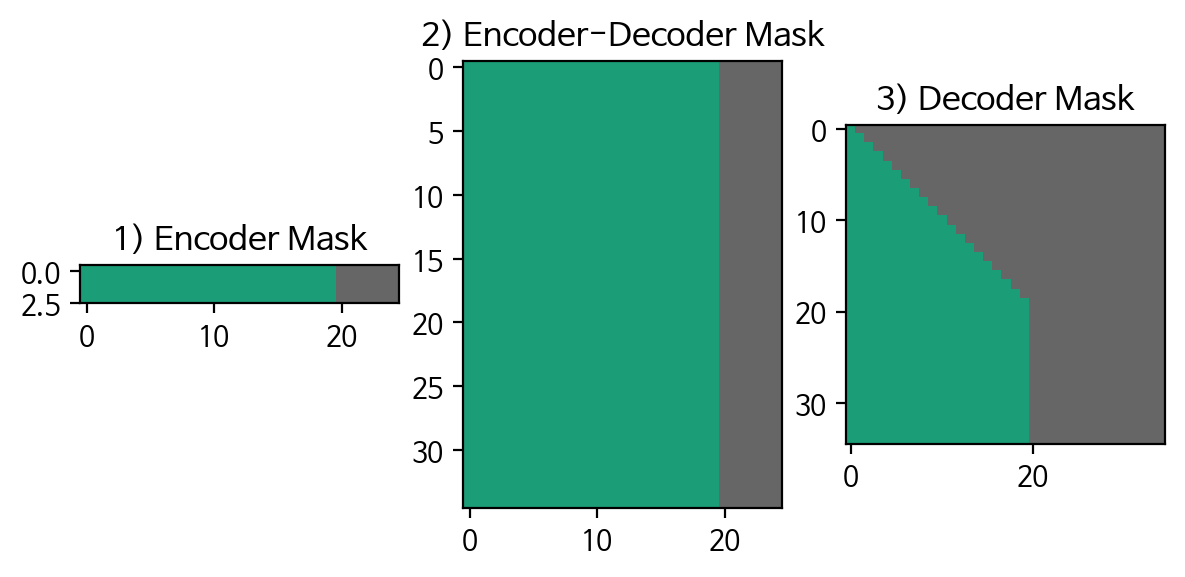

In [18]:
import matplotlib.pyplot as plt

batch, length = 16, 20
src_padding = 5
tgt_padding = 15

src_pad = torch.zeros((batch, src_padding))
tgt_pad = torch.zeros((batch, tgt_padding))

sample_data = torch.ones((batch, length))
sample_src = torch.cat([sample_data, src_pad], dim=-1)
sample_tgt = torch.cat([sample_data, tgt_pad], dim=-1)

enc_mask, dec_enc_mask, dec_mask = generate_masks(sample_src, sample_tgt)

fig = plt.figure(figsize=(7, 7))

ax1 = fig.add_subplot(131)
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

ax1.set_title('1) Encoder Mask')
ax2.set_title('2) Encoder-Decoder Mask')
ax3.set_title('3) Decoder Mask')

ax1.imshow(enc_mask[:3, 0, 0].numpy(), cmap='Dark2')
ax2.imshow(dec_enc_mask[0, 0].expand(sample_tgt.shape[1], -1).numpy(), cmap='Dark2')
ax3.imshow(dec_mask[0, 0].numpy(), cmap='Dark2')

plt.show()

In [19]:
def noam_schedule(d_model, warmup_steps=4000):
    """논문 5.3 절의 수식: lrate = d_model^-0.5 · min(step^-0.5, step · warmup_steps^-1.5)"""
    def lr_lambda(step):
        step = max(step, 1)                       # step 0 에서 0^-0.5 가 되는 것을 방지
        return (d_model ** -0.5) * min(step ** -0.5, step * warmup_steps ** -1.5)
    return lr_lambda

# 연결 예시 — 아무 모델이나 하나 두고 확인해 봅니다
sample_model = nn.Linear(10, 10)

# 논문과 동일한 Adam 설정. lr=1.0 은 "기준값" 이고 실제 lr = 1.0 × lr_lambda(step)
optimizer = optim.Adam(sample_model.parameters(), lr=1.0, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=noam_schedule(d_model=512, warmup_steps=4000))

# 학습 루프에서는 매 step 마다 optimizer.step() 다음에 scheduler.step() 을 호출합니다
for step in range(1, 8001):
    optimizer.step()
    scheduler.step()
    if step in (1, 1000, 4000, 8000):
        print(f"step {step:5d}  lr = {scheduler.get_last_lr()[0]:.2e}")

step     1  lr = 1.75e-07
step  1000  lr = 1.75e-04
step  4000  lr = 6.99e-04
step  8000  lr = 4.94e-04


프로젝트: 더 멋진 번역기 만들기

In [20]:
import torch
import numpy
import matplotlib

print(torch.__version__)
print(numpy.__version__)
print(matplotlib.__version__)

2.11.0+cu128
2.1.3
3.10.0


In [21]:
DATA_DIR = '/content/drive/MyDrive/Aiffel_EPA/transformer/data'

!mkdir -p "{DATA_DIR}"
!wget -nc https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz -P "{DATA_DIR}"
!tar -xzf "{DATA_DIR}/korean-english-park.train.tar.gz" -C "{DATA_DIR}"
!ls -l "{DATA_DIR}"

--2026-09-10 02:34:04--  https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz [following]
--2026-09-10 02:34:04--  https://raw.githubusercontent.com/jungyeul/korean-parallel-corpora/master/korean-english-news-v1/korean-english-park.train.tar.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8718893 (8.3M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/Aiffel_EPA/transformer

In [22]:
kor_path = os.path.join(DATA_DIR, "korean-english-park.train.ko")
eng_path = os.path.join(DATA_DIR, "korean-english-park.train.en")

def clean_corpus(kor_path, eng_path):
    with open(kor_path, "r", encoding="utf-8") as f:
        kor = f.read().splitlines()
    with open(eng_path, "r", encoding="utf-8") as f:
        eng = f.read().splitlines()
    assert len(kor) == len(eng), "한국어·영어 문장 수가 다릅니다"

    # (한국어, 영어) 쌍을 하나의 튜플로 묶어 set 에 넣으면 쌍 단위로 중복이 제거됩니다.
    # dict.fromkeys 는 set 과 같은 중복 제거를 하면서 원래 순서를 유지합니다.
    cleaned_corpus = list(dict.fromkeys(zip(kor, eng)))

    print(f"원본 문장 쌍: {len(kor):,}  →  중복 제거 후: {len(cleaned_corpus):,}")
    return cleaned_corpus

cleaned_corpus = clean_corpus(kor_path, eng_path)
print(cleaned_corpus[0])

원본 문장 쌍: 94,123  →  중복 제거 후: 78,968
('개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"', 'Much of personal computing is about "can you top this?"')


In [23]:
def preprocess_sentence(sentence):
    sentence = sentence.lower()                                # 1. 모든 입력을 소문자로
    sentence = re.sub(r"[^a-z가-힣?.!,]+", " ", sentence)     # 2. 알파벳·한글·문장부호(?.!,) 만 남기고 나머지는 공백으로
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)          # 3. 문장부호 양옆에 공백
    sentence = re.sub(r"\s+", " ", sentence)                   #    연속 공백을 하나로
    return sentence.strip()                                    # 4. 문장 앞뒤 공백 제거

print(preprocess_sentence("Obama, the 44th President,  said: \"Yes we can!\""))
print(preprocess_sentence("  일곱 명의 사망자가 발생했다.  "))

obama , the th president , said yes we can !
일곱 명의 사망자가 발생했다 .


In [24]:
import sentencepiece as spm

def generate_tokenizer(corpus, vocab_size, lang="ko",
                       pad_id=0, bos_id=1, eos_id=2, unk_id=3):
    corpus_path  = os.path.join(DATA_DIR, f"{lang}_corpus.txt")
    model_prefix = os.path.join(DATA_DIR, f"{lang}_spm")

    # 1) 말뭉치를 한 줄에 한 문장씩 파일로 저장 (SentencePiece 는 파일 입력을 받습니다)
    with open(corpus_path, "w", encoding="utf-8") as f:
        for row in corpus:
            f.write(row + "\n")

    # 2) 학습 — 특수 토큰 인덱스를 <PAD>:0 / <BOS>:1 / <EOS>:2 / <UNK>:3 으로 고정
    spm.SentencePieceTrainer.train(
        input=corpus_path,
        model_prefix=model_prefix,
        vocab_size=vocab_size,
        pad_id=pad_id,
        bos_id=bos_id,
        eos_id=eos_id,
        unk_id=unk_id,
    )

    # 3) 저장된 .model 을 Processor 에 Load 한 뒤 반환
    tokenizer = spm.SentencePieceProcessor()
    tokenizer.Load(f"{model_prefix}.model")
    return tokenizer


SRC_VOCAB_SIZE = TGT_VOCAB_SIZE = 20000

kor_corpus = []
eng_corpus = []

for k, e in cleaned_corpus:                  # clean_corpus() 가 (한국어, 영어) 튜플로 저장했습니다
    kor_corpus.append(preprocess_sentence(k))
    eng_corpus.append(preprocess_sentence(e))

ko_tokenizer = generate_tokenizer(kor_corpus, SRC_VOCAB_SIZE, "ko")
en_tokenizer = generate_tokenizer(eng_corpus, TGT_VOCAB_SIZE, "en")
# <BOS>·<EOS> 는 인코딩할 때 add_bos / add_eos 인자로 붙입니다
# (set_encode_extra_options 는 sentencepiece 0.2.1 부터 제거되었습니다)

# 특수 토큰 인덱스와 동작 확인
print("PAD/BOS/EOS/UNK:", en_tokenizer.pad_id(), en_tokenizer.bos_id(), en_tokenizer.eos_id(), en_tokenizer.unk_id())
print(ko_tokenizer.encode_as_pieces(kor_corpus[0]))
print(en_tokenizer.encode_as_ids(eng_corpus[0], add_bos=True, add_eos=True))   # 1 로 시작, 2 로 끝나야 함

PAD/BOS/EOS/UNK: 0 1 2 3
['▁개인', '용', '▁컴퓨터', '▁사용', '의', '▁상당', '▁부분은', '▁이것', '보다', '▁뛰어', '날', '▁수', '▁있느냐', '▁', '?']
[1, 282, 8, 1237, 8799, 17, 47, 95, 93, 210, 42, 77, 3, 2]


In [25]:
from tqdm.notebook import tqdm  # 진행 과정 보기

src_corpus = []
tgt_corpus = []

assert len(kor_corpus) == len(eng_corpus)

# 토큰의 길이가 50 이하인 문장만 남깁니다. 타겟(영문)에는 <BOS>·<EOS> 를 붙입니다.
for idx in tqdm(range(len(kor_corpus))):
    src_tokens = ko_tokenizer.encode_as_ids(kor_corpus[idx])
    tgt_tokens = en_tokenizer.encode_as_ids(eng_corpus[idx], add_bos=True, add_eos=True)

    if len(src_tokens) <= 50 and len(tgt_tokens) <= 50:
        src_corpus.append(torch.tensor(src_tokens, dtype=torch.long))
        tgt_corpus.append(torch.tensor(tgt_tokens, dtype=torch.long))

def pad_sequences(sequences, padding_value=0):
    return torch.nn.utils.rnn.pad_sequence(sequences, batch_first=True, padding_value=padding_value)

# 패딩처리를 완료하여 학습용 데이터를 완성합니다.
enc_train = pad_sequences(src_corpus, padding_value=0)
dec_train = pad_sequences(tgt_corpus, padding_value=0)

print(f"사용 문장 쌍: {len(src_corpus):,} / {len(kor_corpus):,}")
print(enc_train.shape, dec_train.shape)
print(dec_train[0])   # 1 로 시작하고 2 뒤에 0(<PAD>) 이 이어져야 함

  0%|          | 0/78968 [00:00<?, ?it/s]

사용 문장 쌍: 75,567 / 78,968
torch.Size([75567, 50]) torch.Size([75567, 50])
tensor([   1,  282,    8, 1237, 8799,   17,   47,   95,   93,  210,   42,   77,
           3,    2,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0])


In [26]:
transformer = Transformer(
    n_layers=2,
    d_model=512,
    n_heads=8,
    d_ff=2048,
    src_vocab_size=SRC_VOCAB_SIZE,
    tgt_vocab_size=TGT_VOCAB_SIZE,
    pos_len=200,
    dropout=0.2,
    shared=True
).to(device)

In [27]:
optimizer = optim.Adam(transformer.parameters(), lr=1.0,
                       betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.LambdaLR(optimizer,
                                        lr_lambda=noam_schedule(d_model=512,
                                                                warmup_steps=4000))

n_params = sum(p.numel() for p in transformer.parameters())
print(f"파라미터 수: {n_params:,}")

파라미터 수: 35,213,856


In [28]:
loss_object = torch.nn.CrossEntropyLoss(ignore_index=0)   # <PAD>=0 은 loss 계산과 평균의 분모에서 모두 제외

def loss_function(real, pred):
    """
    real : 정답 토큰 id      [batch, tgt_len]
    pred : 모델 출력 logits  [batch, tgt_len, vocab_size]
    """
    return loss_object(pred.reshape(-1, pred.size(-1)),   # [batch*tgt_len, vocab_size]
                       real.reshape(-1))                  # [batch*tgt_len]

In [29]:
def train_step(src, tgt, model, optimizer, scheduler):
    model.train()
    src, tgt = src.to(device), tgt.to(device)

    # 디코더 입력은 <BOS> w1 w2 … , 정답은 w1 w2 … <EOS>  (한 칸 어긋나게)
    dec_in = tgt[:, :-1]
    gold   = tgt[:, 1:]

    # 입력 데이터에 알맞은 Mask 생성
    enc_mask, dec_enc_mask, dec_mask = generate_masks(src, dec_in)

    # 계산된 loss 에 대해 역전파(Backpropagation)를 적용해 학습을 진행합니다.
    optimizer.zero_grad()
    predictions, enc_attns, dec_attns, dec_enc_attns = model(src, dec_in, enc_mask, dec_enc_mask, dec_mask)
    loss = loss_function(gold, predictions)
    loss.backward()

    optimizer.step()
    scheduler.step()          # 논문의 lr 스케줄은 step 단위로 갱신

    return loss.item(), enc_attns, dec_attns, dec_enc_attns

In [30]:
# Attention 시각화 함수

def visualize_attention(src, tgt, enc_attns, dec_attns, dec_enc_attns, n_heads=4):
    """
    src / tgt      : 축 라벨로 쓸 토큰 조각 리스트 (소스 조각, <BOS> + 생성 조각)
    enc_attns 등   : 층별 어텐션 가중치 리스트, 각 원소 [batch, heads, q_len, k_len]
    n_heads        : 한 줄에 그릴 head 수 (모델 head 수 이하)
    """
    def draw(data, ax, x="auto", y="auto"):
        seaborn.heatmap(data.detach().cpu().numpy(),     # grad 분리 → CPU → numpy
                        square=True,
                        vmin=0.0, vmax=1.0,
                        cbar=False, ax=ax,
                        xticklabels=x,
                        yticklabels=y)

    for layer in range(len(enc_attns)):
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        print("Encoder Layer", layer + 1)
        for h in range(n_heads):
            draw(enc_attns[layer][0, h, :len(src), :len(src)], axs[h], src, src)
        plt.show()

    for layer in range(len(dec_attns)):
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        print("Decoder Self Layer", layer + 1)
        for h in range(n_heads):
            draw(dec_attns[layer][0, h, :len(tgt), :len(tgt)], axs[h], tgt, tgt)
        plt.show()

        print("Decoder Src Layer", layer + 1)
        fig, axs = plt.subplots(1, n_heads, figsize=(20, 10))
        for h in range(n_heads):
            draw(dec_enc_attns[layer][0, h, :len(tgt), :len(src)], axs[h], src, tgt)
        plt.show()

In [31]:
# 번역 생성 함수

def evaluate(sentence, model, src_tokenizer, tgt_tokenizer, max_len=None):
    model.eval()                                            # dropout 끄기
    max_len = max_len or dec_train.shape[-1]                # 기본: 학습 데이터의 최대 길이

    sentence = preprocess_sentence(sentence)
    # 시각화 축 라벨용 조각. SentencePiece 의 단어 경계 기호 '▁'(U+2581) 는 나눔 폰트에 없어 제거
    pieces = [p.replace('▁', '') for p in src_tokenizer.encode_as_pieces(sentence)]
    tokens = src_tokenizer.encode_as_ids(sentence)
    _input = torch.tensor(tokens, device=device).unsqueeze(0)          # [1, src_len]

    ids = []
    output = torch.tensor([[tgt_tokenizer.bos_id()]], device=device)   # [1, 1] — <BOS> 로 시작

    with torch.no_grad():                                   # 추론에는 그래프가 필요 없음
        for _ in range(max_len):
            enc_mask, dec_enc_mask, dec_mask = generate_masks(_input, output)
            predictions, enc_attns, dec_attns, dec_enc_attns = \
                model(_input, output, enc_mask, dec_enc_mask, dec_mask)

            predicted_id = predictions[0, -1].argmax().item()   # 마지막 위치의 최댓값 = 다음 토큰

            if predicted_id == tgt_tokenizer.eos_id():
                break

            ids.append(predicted_id)
            output = torch.cat([output, torch.tensor([[predicted_id]], device=device)], dim=-1)

    result = tgt_tokenizer.decode_ids(ids)
    tgt_pieces = ['<BOS>'] + [tgt_tokenizer.id_to_piece(i).replace('▁', '') for i in ids]   # 디코더 입력 위치와 1:1

    return pieces, tgt_pieces, result, enc_attns, dec_attns, dec_enc_attns

In [32]:
# 번역 생성 및 Attention 시각화 결합

def translate(sentence, model, src_tokenizer, tgt_tokenizer, plot_attention=False):
    pieces, tgt_pieces, result, enc_attns, dec_attns, dec_enc_attns = \
        evaluate(sentence, model, src_tokenizer, tgt_tokenizer)

    print('Input: %s' % (sentence))
    print('Predicted translation: {}'.format(result))

    if plot_attention:
        visualize_attention(pieces, tgt_pieces, enc_attns, dec_attns, dec_enc_attns)

In [33]:
# 학습 실행 — 예문 번역은 epoch 마다, Attention Map 은 학습이 끝난 뒤 한 번
from tqdm import tqdm

BATCH_SIZE = 64
EPOCHS = 5          # 하이퍼파라미터는 자유롭게 조절하세요

examples = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

for epoch in range(EPOCHS):
    total_loss = 0.0

    idx_list = list(range(0, enc_train.shape[0], BATCH_SIZE))
    random.shuffle(idx_list)
    t = tqdm(idx_list)

    for batch, idx in enumerate(t):
        batch_loss, enc_attns, dec_attns, dec_enc_attns = train_step(
            enc_train[idx:idx+BATCH_SIZE],
            dec_train[idx:idx+BATCH_SIZE],
            transformer,
            optimizer,
            scheduler)

        total_loss += batch_loss                      # float

        t.set_description('Epoch %2d' % (epoch + 1))
        t.set_postfix({'Loss': '%.4f' % (total_loss / (batch + 1)),
                       'lr': '%.2e' % scheduler.get_last_lr()[0]})

    for example in examples:
        translate(example, transformer, ko_tokenizer, en_tokenizer)

Epoch  1: 100%|██████████| 1181/1181 [03:07<00:00,  6.30it/s, Loss=7.1409, lr=2.06e-04]


Input: 오바마는 대통령이다.
Predicted translation: the united states is a year .
Input: 시민들은 도시 속에 산다.
Predicted translation: the united states is a year old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old old
Input: 커피는 필요 없다.
Predicted translation: the united states is a year .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the united states states in the united states , the united states .


Epoch  2: 100%|██████████| 1181/1181 [03:12<00:00,  6.13it/s, Loss=5.6023, lr=4.13e-04]


Input: 오바마는 대통령이다.
Predicted translation: obama s president president president bush .
Input: 시민들은 도시 속에 산다.
Predicted translation: the streets of the streets of the streets of the streets .
Input: 커피는 필요 없다.
Predicted translation: we will be a good .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the two people were killed in the city of the city of the city .


Epoch  3: 100%|██████████| 1181/1181 [03:11<00:00,  6.16it/s, Loss=5.0003, lr=6.19e-04]


Input: 오바마는 대통령이다.
Predicted translation: obama is the president .
Input: 시민들은 도시 속에 산다.
Predicted translation: the city of the city is the second place .
Input: 커피는 필요 없다.
Predicted translation: you don t be a lot of the world .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the death toll was killed in the death of the death toll .


Epoch  4: 100%|██████████| 1181/1181 [03:11<00:00,  6.17it/s, Loss=4.6047, lr=6.43e-04]


Input: 오바마는 대통령이다.
Predicted translation: obama is a way to be a country .
Input: 시민들은 도시 속에 산다.
Predicted translation: the city of cities in the city of cities .
Input: 커피는 필요 없다.
Predicted translation: there s no longer .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the death toll was killed .


Epoch  5: 100%|██████████| 1181/1181 [03:11<00:00,  6.17it/s, Loss=4.2452, lr=5.75e-04]


Input: 오바마는 대통령이다.
Predicted translation: obama is the president .
Input: 시민들은 도시 속에 산다.
Predicted translation: many cities are the top of the city .
Input: 커피는 필요 없다.
Predicted translation: there is no risk of coffee .
Input: 일곱 명의 사망자가 발생했다.
Predicted translation: the death toll was killed in the sunday .


Input: 오바마는 대통령이다.
Predicted translation: obama is the president .
Encoder Layer 1


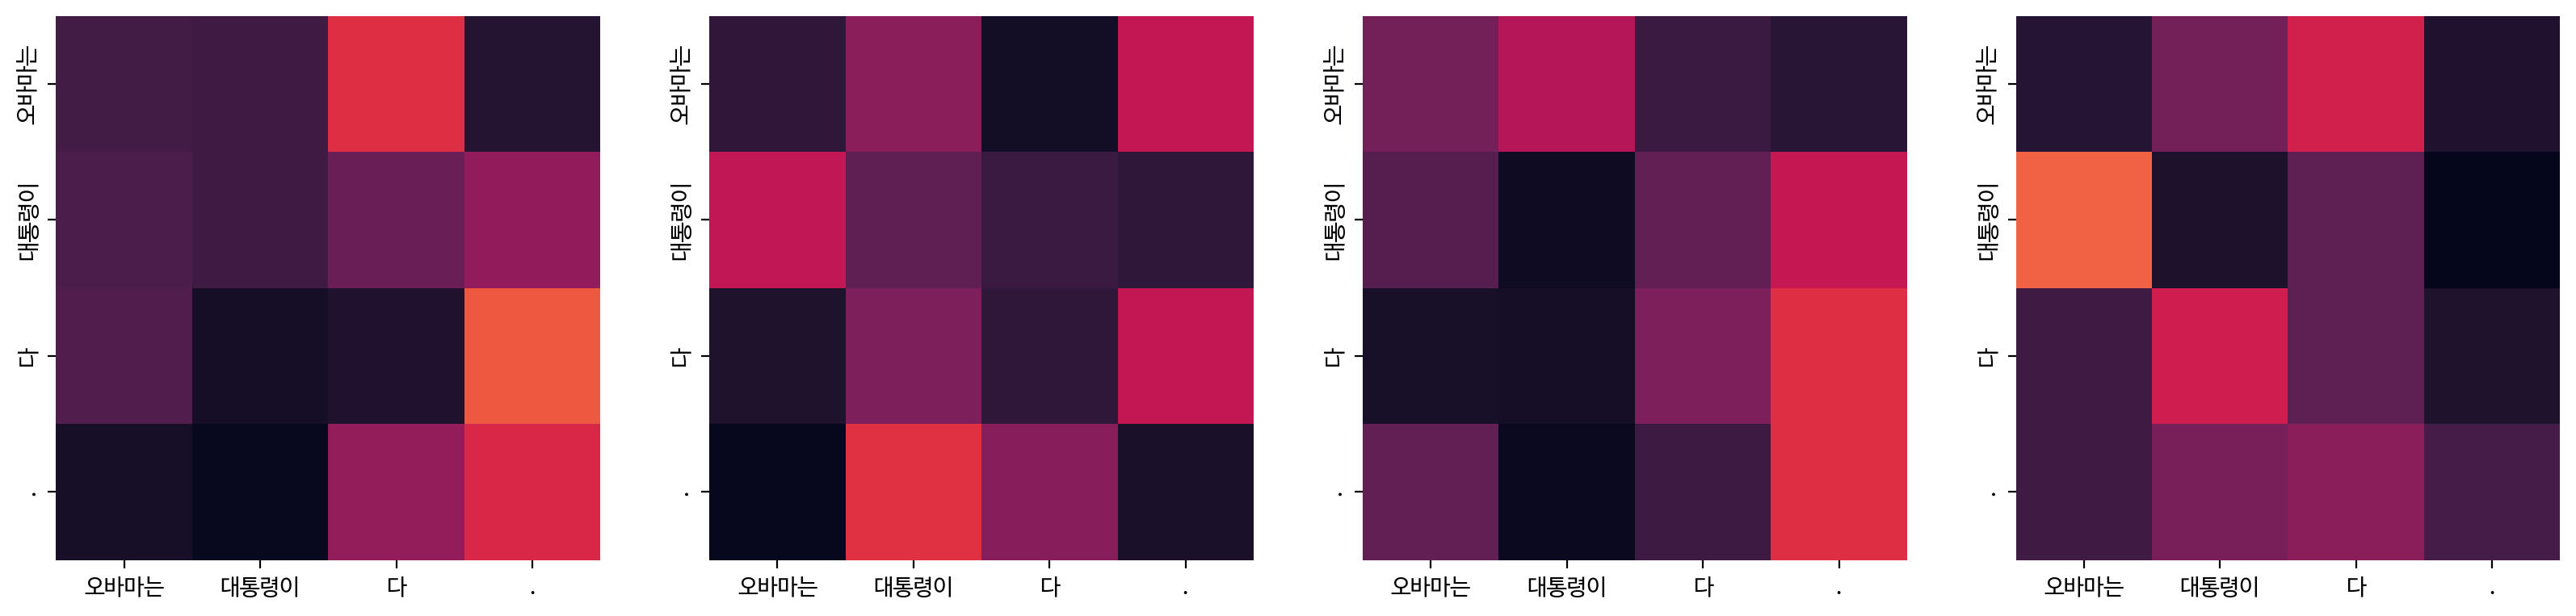

Encoder Layer 2


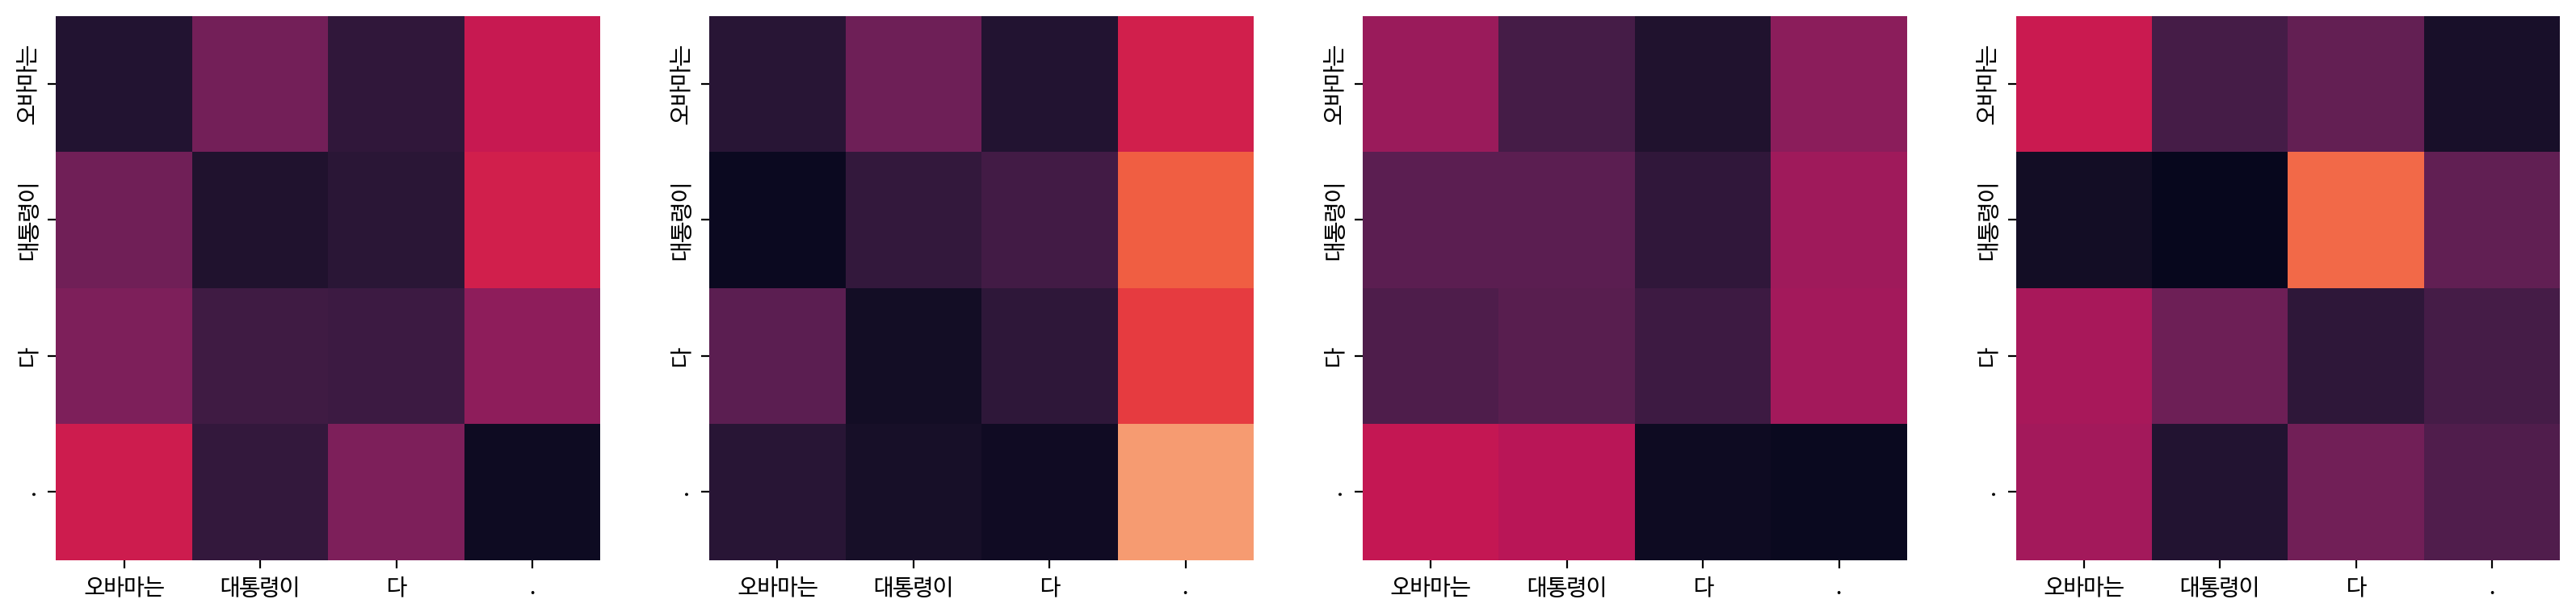

Decoder Self Layer 1


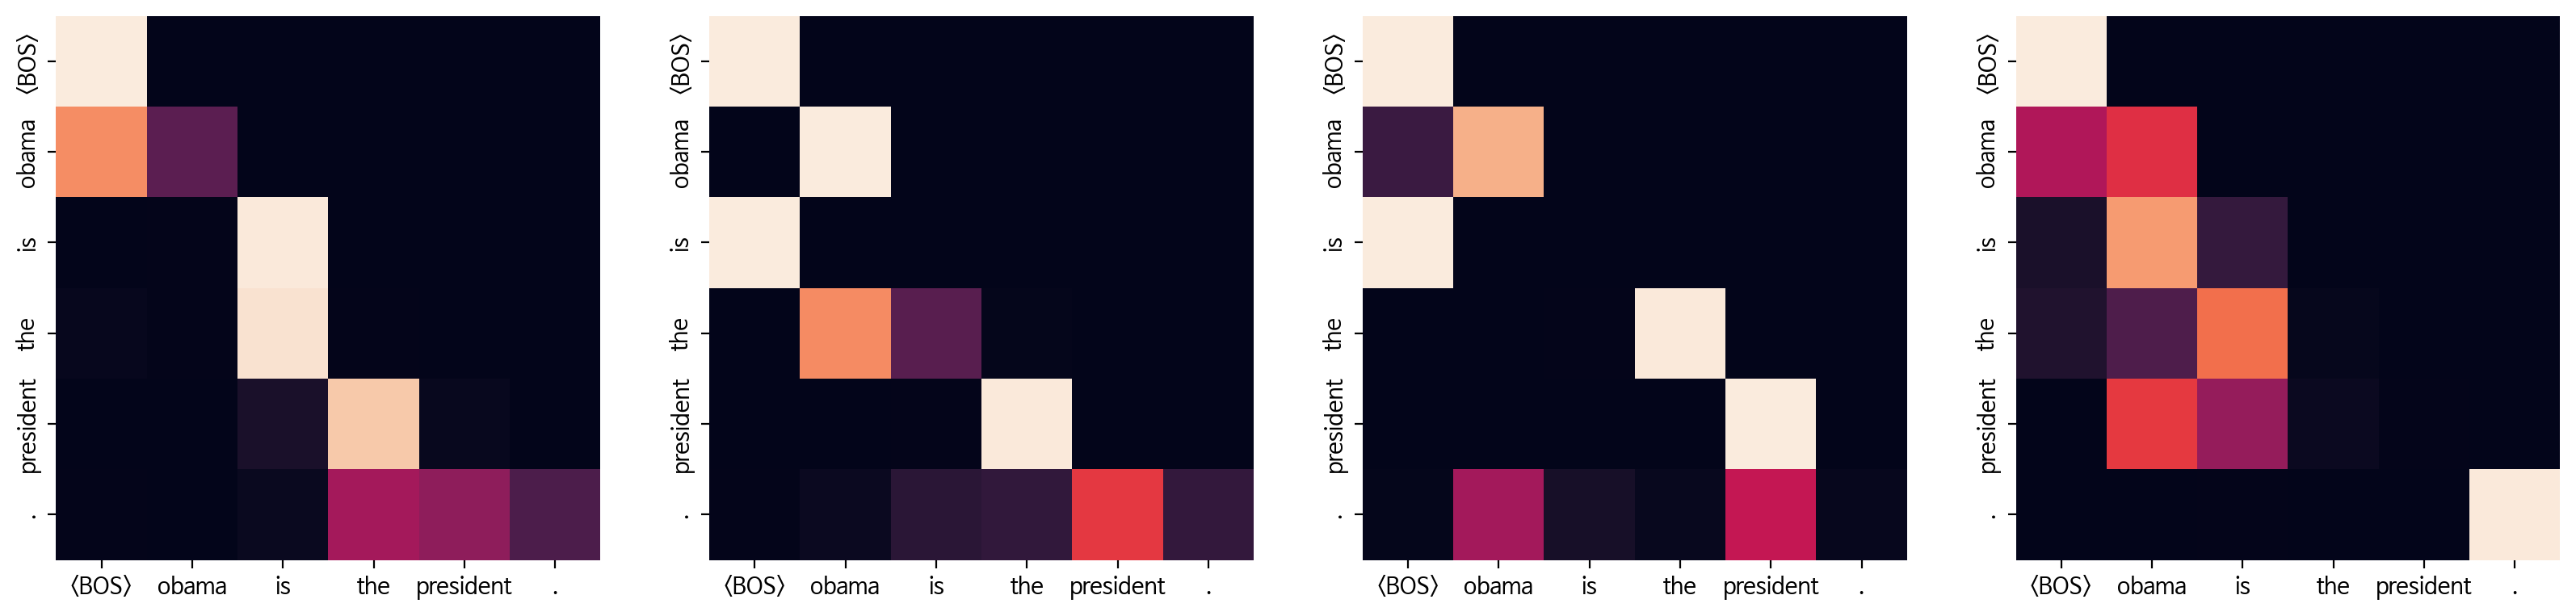

Decoder Src Layer 1


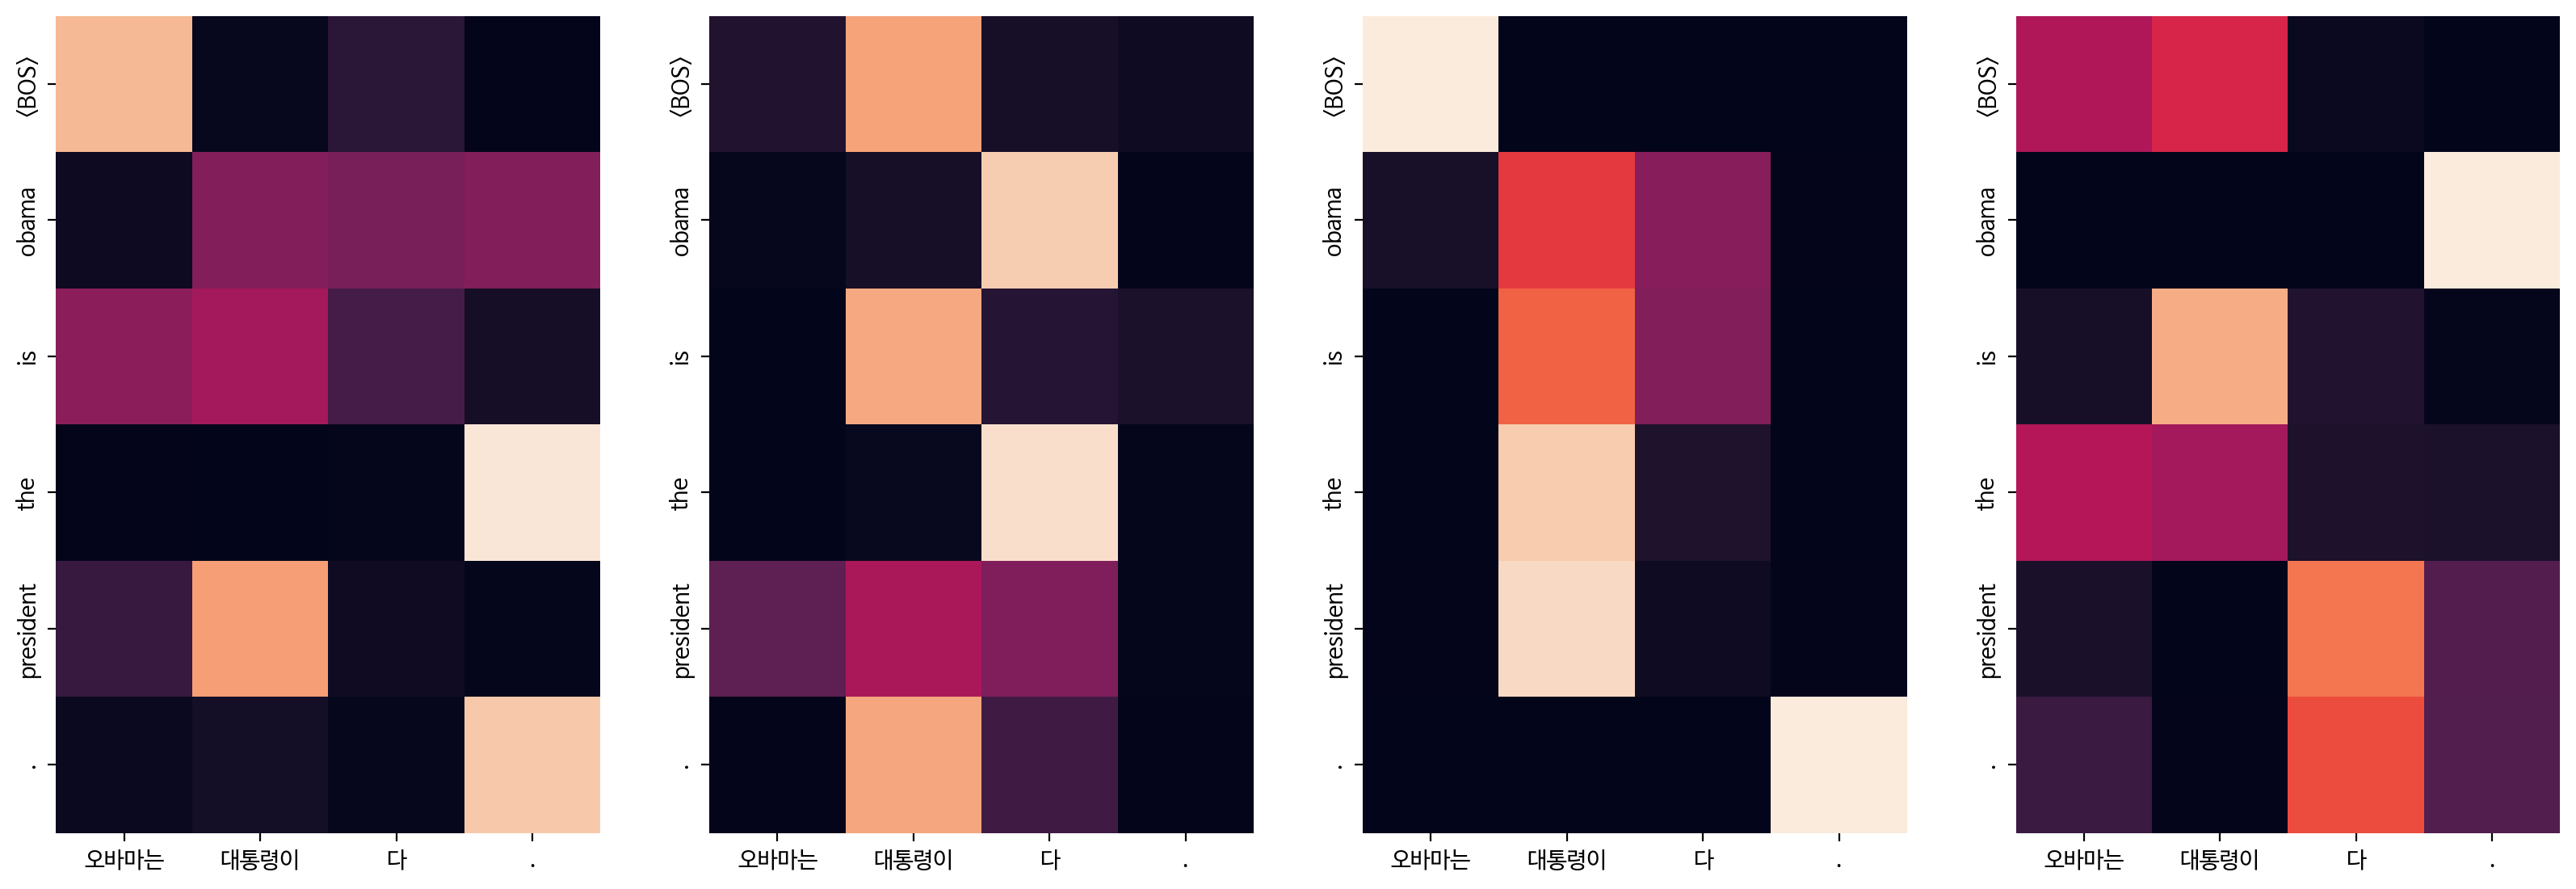

Decoder Self Layer 2


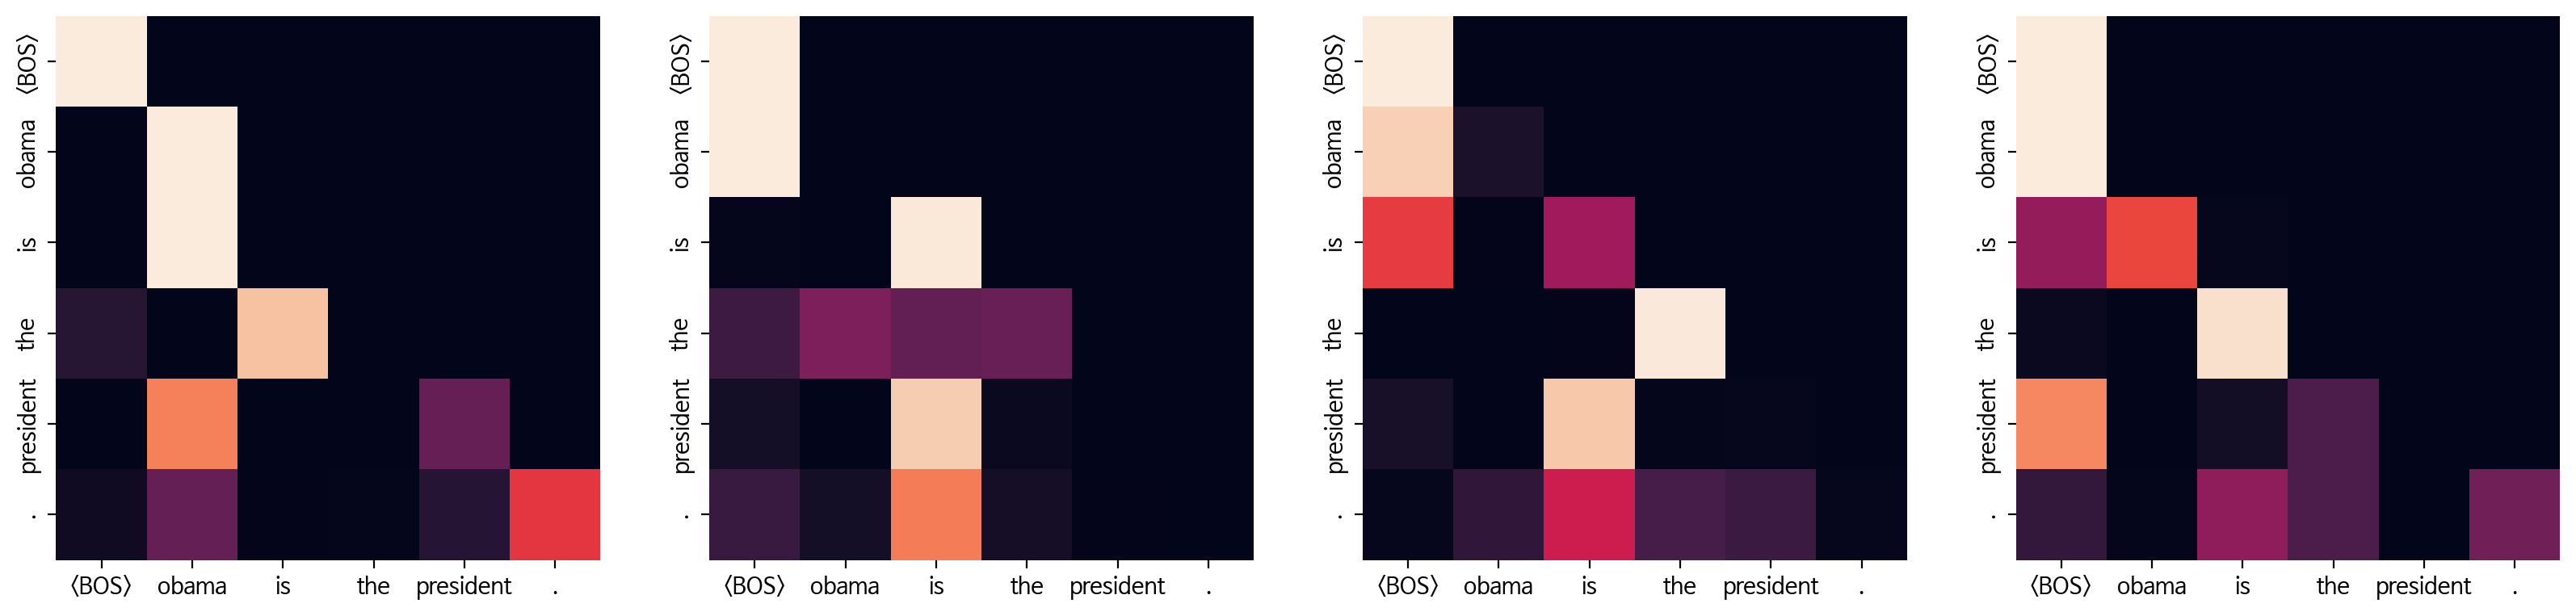

Decoder Src Layer 2


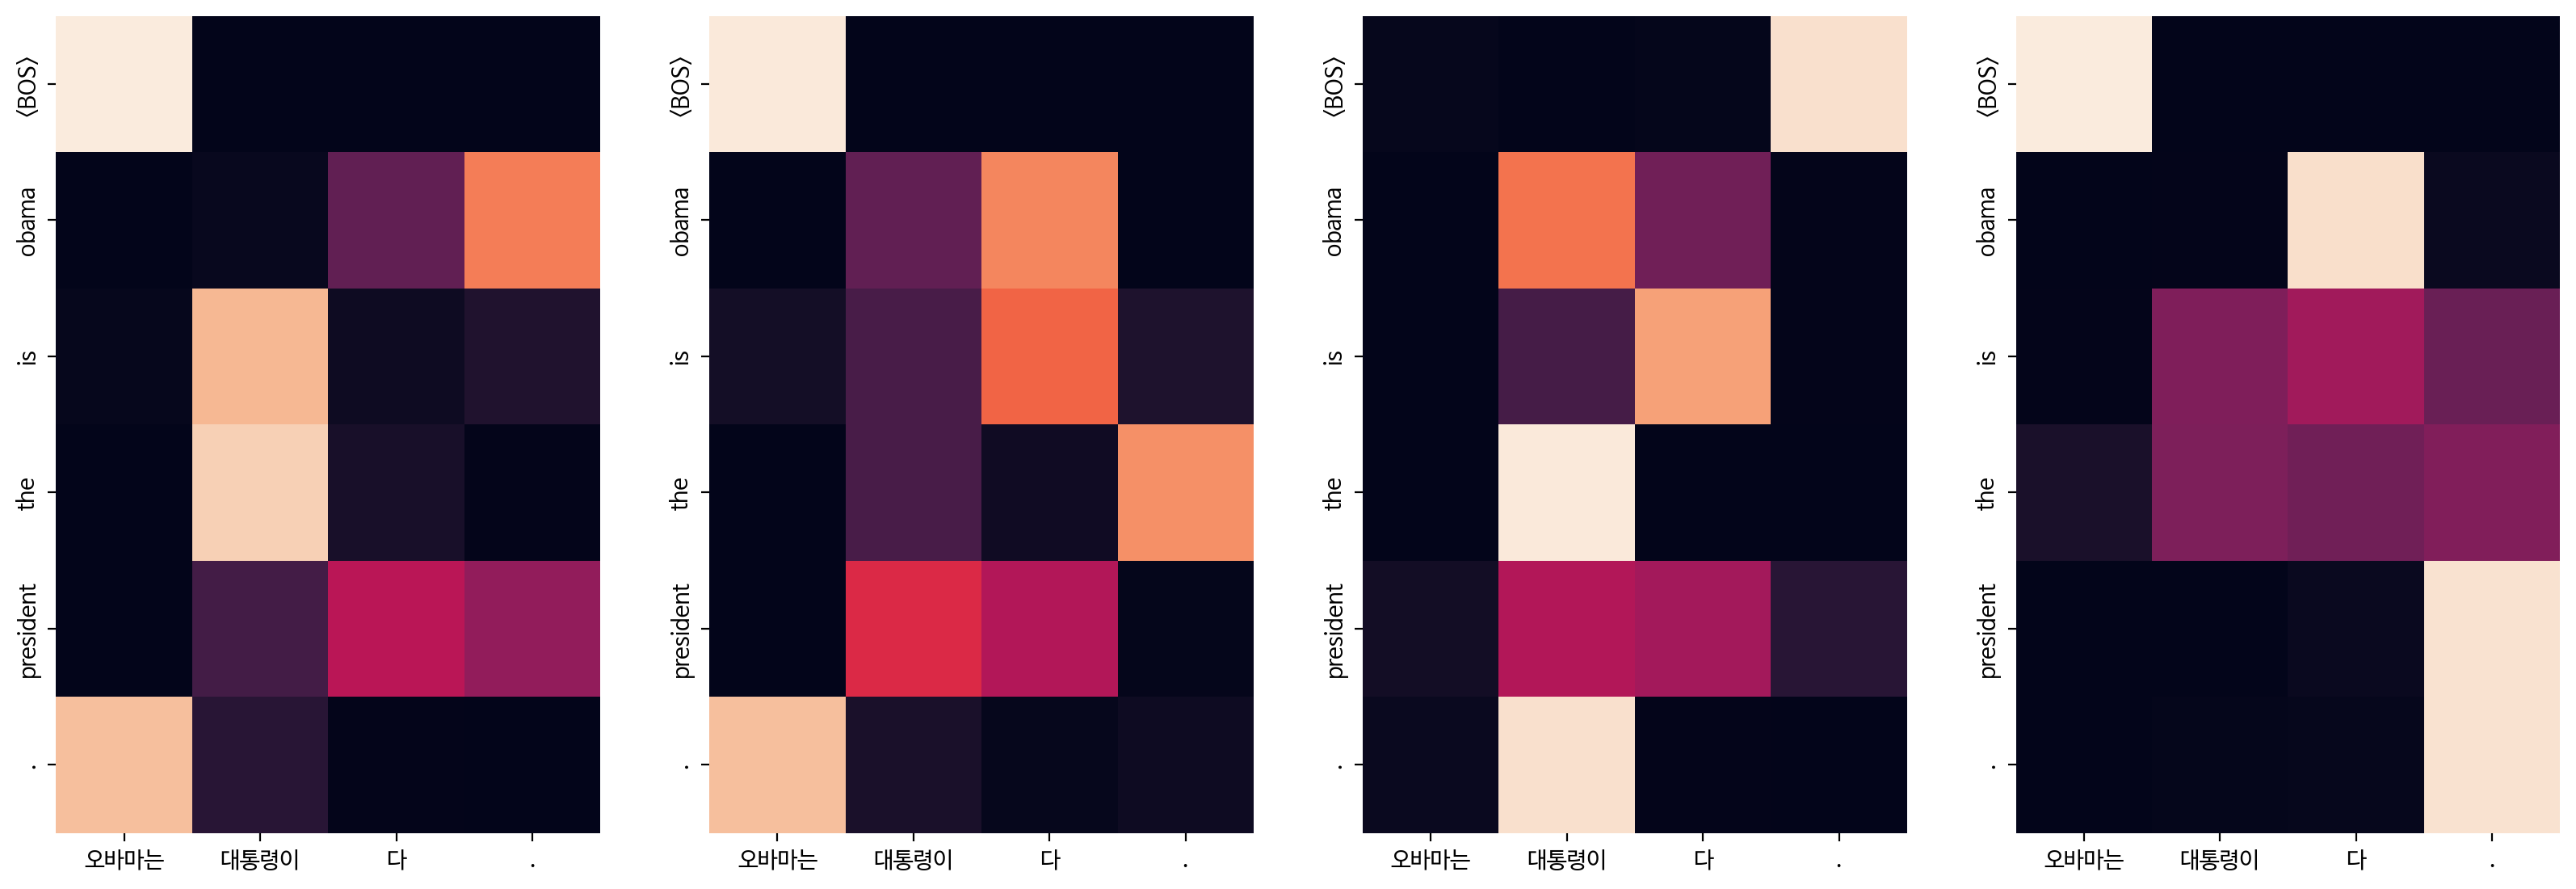

In [34]:
# 학습이 끝난 뒤 Attention Map 확인
translate(examples[0], transformer, ko_tokenizer, en_tokenizer, plot_attention=True)